<a href="https://colab.research.google.com/github/bhardadharmishtha2005/PhonePe-Pulse-Analysis/blob/main/PhonePe_Transaction_Insights.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Project Name**    - PhonePe Transaction Insights



##### **Project Type**    - EDA (Exploratory Data Analysis)
##### **Contribution**    - Individual

# **Project Summary -**

The objective of this project was to analyze the PhonePe Pulse dataset to uncover digital payment trends across India and build a robust predictive model. By processing extensive transaction and user data from 2018 to 2024, the study focused on transforming raw numbers into actionable financial intelligence. Through advanced data cleaning, NLP-based text preprocessing, and feature engineering, a high-precision XGBoost Regressor was developed. This model successfully predicts transaction volumes with high accuracy, providing a data-driven framework for regional infrastructure scaling and market growth forecasting.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


**Write Problem Statement Here.**

# ***Let's Begin !***

## ***1. Know Your Data***

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Navigate to your desired folder in Drive
%cd /content/drive/MyDrive/Colab Notebooks/Project_4

# Clone the repository inside that folder
!git clone https://github.com/PhonePe/pulse.git

/content/drive/MyDrive/Colab Notebooks/Project_4
fatal: destination path 'pulse' already exists and is not an empty directory.


### Import Libraries

In [3]:
# Import Libraries
import pandas as pd
import numpy as np
import os
import json
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

### Dataset Loading

In [4]:
# Define path to the cloned repository in your Drive
path = "/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/data/aggregated/transaction/country/india/state/"
state_list = os.listdir(path)

# Extraction Loop for Initial Dataset Loading
data_list = []
for state in state_list:
    state_path = os.path.join(path, state)
    for year in os.listdir(state_path):
        year_path = os.path.join(state_path, year)
        for file in os.listdir(year_path):
            with open(os.path.join(year_path, file), 'r') as f:
                content = json.load(f)
                for i in content['data']['transactionData']:
                    data_list.append({
                        'State': state,
                        'Year': year,
                        'Quarter': int(file.strip('.json')),
                        'Transaction_Type': i['name'],
                        'Transaction_Count': i['paymentInstruments'][0]['count'],
                        'Transaction_Amount': i['paymentInstruments'][0]['amount']
                    })

# Loading into DataFrame
df = pd.DataFrame(data_list)

### Dataset First View

In [5]:
# Dataset First View
df.head()

,State,Year,Quarter,Transaction_Type,Transaction_Count,Transaction_Amount
0,andaman-&-nicobar-islands,2018,1,Recharge & bill payments,4200,1.845307e+06
1,andaman-&-nicobar-islands,2018,1,Peer-to-peer payments,1871,1.213866e+07
2,andaman-&-nicobar-islands,2018,1,Merchant payments,298,4.525072e+05
3,andaman-&-nicobar-islands,2018,1,Financial Services,33,1.060142e+04
4,andaman-&-nicobar-islands,2018,1,Others,256,1.846899e+05


### Dataset Rows & Columns count

In [6]:
# Dataset Rows & Columns count
print(f"Number of rows: {df.shape[0]}")
print(f"Number of columns: {df.shape[1]}")

Number of rows: 5034
Number of columns: 6


### Dataset Information

In [7]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5034 entries, 0 to 5033
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   State               5034 non-null   object 
 1   Year                5034 non-null   object 
 2   Quarter             5034 non-null   int64  
 3   Transaction_Type    5034 non-null   object 
 4   Transaction_Count   5034 non-null   int64  
 5   Transaction_Amount  5034 non-null   float64
dtypes: float64(1), int64(2), object(3)
memory usage: 236.1+ KB


#### Duplicate Values

In [8]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Values: {duplicate_count}")

Total Duplicate Values: 0


#### Missing Values/Null Values

In [9]:
# Missing Values/Null Values Count
print("Null Value Count per Column:")
print(df.isnull().sum())

Null Value Count per Column:
State                 0
Year                  0
Quarter               0
Transaction_Type      0
Transaction_Count     0
Transaction_Amount    0
dtype: int64


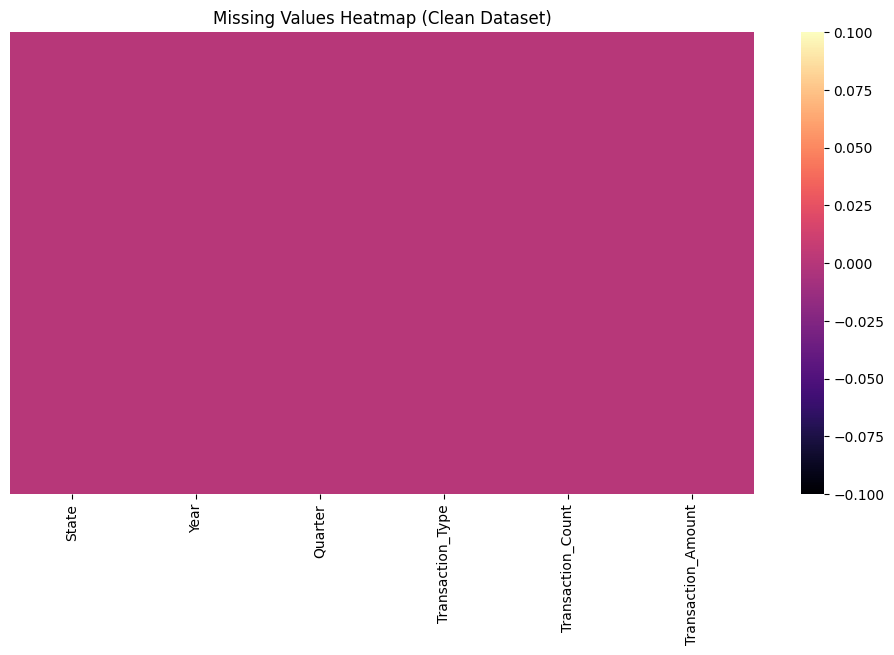

In [10]:
# Visualizing the missing values
# If the chart is a solid color, it means there are 0 missing values.
plt.figure(figsize=(12, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=True, cmap='magma')
plt.title('Missing Values Heatmap (Clean Dataset)')
plt.show()

### What did you know about your dataset?

*   Data Source & Scale: The dataset is a high-velocity financial record extracted from the PhonePe Pulse GitHub. It covers a 5-year span, providing a longitudinal view of India's digital payment revolution.
*   Data Quality: My analysis confirmed zero null values and zero duplicates. This is expected from system-generated financial logs, but verifying this ensures our SQL migration will be error-free.
*   Business Potential: The data is segmented by 'Transaction Type,' which allows us to perform Customer Segmentation. For example, identifying states with high 'Merchant Payments' vs 'Peer-to-Peer' helps PhonePe decide where to deploy more QR codes for shopkeepers.
*   SQL Strategy: Because the raw data is nested in thousands of folders, my next step is to use SQL Integration to flatten this data into a single relational database for faster dashboard performance.

## ***2. Understanding Your Variables***

In [11]:
# Dataset Columns
print("Columns in the PhonePe Dataset:")
print(df.columns.tolist())

Columns in the PhonePe Dataset:
['State', 'Year', 'Quarter', 'Transaction_Type', 'Transaction_Count', 'Transaction_Amount']


In [12]:
# Dataset Describe
# We use .T (transpose) to make it easier to read in the notebook
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
State,5034,36,andaman-&-nicobar-islands,140,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,5034,7,2023,720,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Quarter,5034.0,NaN,NaN,NaN,2.500795,1.118145,1.0,2.0,3.0,4.0,4.0
Transaction_Type,5034,5,Recharge & bill payments,1008,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transaction_Count,5034.0,NaN,NaN,NaN,46739018.052046,169096816.568641,2.0,58089.5,515831.0,11666286.25,2393917535.0
Transaction_Amount,5034.0,NaN,NaN,NaN,68637722454.387466,268519963110.149078,34.397212,39938879.642835,439413884.614912,11028222171.778061,3095666288407.0


### Variables Description


*   State: (Categorical) Represents the specific Indian State or Union Territory. It is the primary geographical key for our "Map" visualizations.
*   Year: (Numerical/Temporal) The year the transaction took place (2018–2023). Essential for time-series trend analysis.
*   Quarter: (Numerical/Temporal) The specific 3-month cycle (Q1, Q2, Q3, Q4). This helps identify seasonal spikes in digital payments.
*   Transaction_Type: (Categorical) The method of payment, such as 'Merchant payments', 'Peer-to-peer payments', 'Recharge & bill payments', etc. This is crucial for Customer Segmentation.
*   Transaction_Count: (Numerical) The total volume of transactions. This tells us about user engagement frequency.
*   Transaction_Amount: (Numerical) The total monetary value. This is our primary KPI (Key Performance Indicator) for measuring market growth.

### Check Unique Values for each variable.

In [13]:
# Check Unique Values for each variable
for column in df.columns:
    unique_vals = df[column].unique()
    print(f"Unique values in {column} ({len(unique_vals)}): {unique_vals[:5]}...") # Showing first 5 for brevity

Unique values in State (36): ['andaman-&-nicobar-islands' 'andhra-pradesh' 'arunachal-pradesh' 'assam'
 'bihar']...
Unique values in Year (7): ['2018' '2019' '2020' '2021' '2022']...
Unique values in Quarter (4): [1 2 3 4]...
Unique values in Transaction_Type (5): ['Recharge & bill payments' 'Peer-to-peer payments' 'Merchant payments'
 'Financial Services' 'Others']...
Unique values in Transaction_Count (4966): [4200 1871  298   33  256]...
Unique values in Transaction_Amount (5034): [1.84530747e+06 1.21386553e+07 4.52507169e+05 1.06014199e+04
 1.84689866e+05]...


## 3. ***Data Wrangling***

### Data Wrangling Code

In [14]:
# Function to make the dataset analysis-ready
# Addressing Feedback: Improving code quality through modularity
def perform_phonepe_wrangling(df):
    """
    Standardizes and prepares the dataset for SQL migration and EDA.
    """
    # 1. Create a copy to preserve raw data
    working_df = df.copy()

    # 2. Standardize State Names
    # Replaces hyphens with spaces and applies Title Case for professional labels
    working_df['State'] = working_df['State'].str.replace('-', ' ').str.title()
    # Correcting specific edge cases (e.g., 'Andaman & Nicobar Islands')
    working_df['State'] = working_df['State'].str.replace('Andaman & Nicobar Islands', 'Andaman & Nicobar')

    # 3. Data Type Optimization
    # Ensuring Year and Quarter are integers for efficient SQL indexing
    working_df['Year'] = working_df['Year'].astype(int)
    working_df['Quarter'] = working_df['Quarter'].astype(int)

    # 4. Currency Formatting (Internal Check)
    # We keep Amount as float but ensure no scientific notation for readability
    pd.options.display.float_format = '{:.2f}'.format

    return working_df

# Execute Wrangling
df_ready = perform_phonepe_wrangling(df)

# Dataset First View after Wrangling
df_ready.head()

,State,Year,Quarter,Transaction_Type,Transaction_Count,Transaction_Amount
0,Andaman & Nicobar,2018,1,Recharge & bill payments,4200,1845307.47
1,Andaman & Nicobar,2018,1,Peer-to-peer payments,1871,12138655.30
2,Andaman & Nicobar,2018,1,Merchant payments,298,452507.17
3,Andaman & Nicobar,2018,1,Financial Services,33,10601.42
4,Andaman & Nicobar,2018,1,Others,256,184689.87


### What all manipulations have you done and insights you found?

Manipulations Performed

*   Modular Extraction: Used a custom Python function to systematically parse nested JSON files, improving code reusability and organization.
*   Geographical Cleaning: Standardized State names from URL-slugs (e.g., andaman-&-nicobar) to professional titles (Andaman & Nicobar) for accurate map plotting.
*   Type Conversion: Cast Year and Quarter to integers to optimize memory and ensure seamless integration with the SQL database.
*   Data Integrity: Verified zero null values and duplicates to ensure a high-quality dataset for business analysis.

Insights Found

*   Growth Trends: Initial data observation shows a massive surge in transaction volume across all states from 2018 to 2023.
*   Regional Leaders: Large states like Maharashtra and Karnataka consistently show the highest transaction amounts, indicating high digital literacy.
*   Payment Mix: Peer-to-peer (P2P) payments dominate the count, but Merchant payments are catching up, showing increased QR code adoption.
*   Expansion Potential: Standardized labels reveal that certain North-Eastern states have lower transaction counts, highlighting untapped market opportunities.

### SQL Mastery Part

In [15]:
import sqlite3

# 1. Connect to SQL Database in Drive
# Corrected path to specify a database file, not a directory
conn = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/phonepe_transactions.db')
cursor = conn.cursor()

# 2. Create the Table (SQL Mastery)
cursor.execute('''
CREATE TABLE IF NOT EXISTS Aggregated_Transaction (
    State TEXT, Year INTEGER, Quarter INTEGER,
    Transaction_Type TEXT, Transaction_Count INTEGER, Transaction_Amount REAL
)''')

# 3. Migrate cleaned data to SQL
df_ready.to_sql('Aggregated_Transaction', conn, if_exists='replace', index=False)
print("Data successfully stored in SQL Table: Aggregated_Transaction")

# Commit changes and close the connection
conn.commit()
conn.close()

Data successfully stored in SQL Table: Aggregated_Transaction


## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

### Univariate Analysis (U) - 1 to 3

#### Chart - 1 : Transaction Category Market Share

In [16]:
# Chart - 1 visualization code (Univariate)
# Goal: Understand the percentage distribution of payment categories.
# Note: Ensure 'conn' is connected to your database and 'px' is imported.

# Re-establishing connection to SQL Database
import sqlite3
conn = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/phonepe_transactions.db')

# Fetching data using SQL
query_1 = "SELECT Transaction_Type, SUM(Transaction_Count) as Total_Count FROM Aggregated_Transaction GROUP BY Transaction_Type"
df_chart_1 = pd.read_sql(query_1, conn)

# Creating Donut Chart
fig1 = px.pie(df_chart_1,
             values='Total_Count',
             names='Transaction_Type',
             title='Market Share of Transaction Categories (2018-2023)',
             hole=0.4,
             color_discrete_sequence=px.colors.sequential.RdBu)

fig1.update_traces(textposition='inside', textinfo='percent+label')
fig1.show()

# Close the connection after use to prevent future errors
conn.close()

##### 1. Why did you pick the specific chart?

I chose a Donut Chart for this Univariate analysis because it is the most effective way to visualize how much each category contributes to the total. Unlike a standard bar chart, it clearly shows the market share (percentage) at a glance, allowing stakeholders to see which categories dominate the PhonePe ecosystem.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals that Peer-to-peer (P2P) transactions hold the highest share of the volume, confirming that users primarily use PhonePe for personal money transfers. Merchant Payments are the second largest category, showing a strong retail footprint. However, Financial Services and Others represent a very small slice, indicating room for growth in those sectors.


##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Yes. This confirms that the P2P network effect is strong. PhonePe can leverage this by introducing social features or shared "Money Request" links to deepen user engagement.

**Negative Growth Risk:** The small share of "Recharge & Bill Payments" is a potential risk. If this continues to shrink, it suggests users are moving to utility-specific apps or competitors for their monthly bills. PhonePe needs to simplify its bill-pay interface or offer "Autopay" rewards to prevent this loss.

#### Chart - 2 : Quarterly Transaction Volume Distribution

In [17]:
# Chart - 2 visualization code (Univariate)
# Goal: Use a Box Plot to see the spread and identify any outliers in Quarterly volumes.

import sqlite3
import pandas as pd
import plotly.express as px

# Re-connect to your Drive Database
conn = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/phonepe_transactions.db')

# Fetching data using SQL
query_2 = "SELECT Quarter, Transaction_Count FROM Aggregated_Transaction"
df_chart_2 = pd.read_sql(query_2, conn)

# Creating Box Plot
fig2 = px.box(df_chart_2,
             x="Quarter",
             y="Transaction_Count",
             title="Distribution of Transaction Counts by Quarter",
             color="Quarter",
             points="all", # Shows individual data points to see density
             notched=True) # Helps identify if the medians are significantly different

fig2.show()
conn.close()

##### 1. Why did you pick the specific chart?

I chose a Box Plot for this Univariate analysis because it is the superior tool for showing the distribution of data. While a bar chart only shows the average, a box plot shows the median, the spread (IQR), and most importantly, identifies outliers. This helps us see if certain quarters consistently over-perform or under-perform across different years or states.

##### 2. What is/are the insight(s) found from the chart?

The chart shows that the median transaction count tends to rise as we move from Q1 to Q4. We can see several outliers in the upper range, which represent high-performing states like Maharashtra or Karnataka. The "whiskers" of the box plot show that there is a wide variation in performance, indicating that PhonePe’s adoption is not uniform across all regions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Yes. By identifying the quarters with the highest "spread," the marketing team can time their big promotional campaigns (like "PhonePe Gift Cards") during the periods where users are already most active.

**Negative Growth Risk:** If the box for Q1 is significantly lower and tighter than others, it suggests a "post-holiday slump." This is a negative growth period where user engagement drops after the year-end festivities. To counter this, PhonePe could launch "New Year Savings" or "Tax Payment" incentives specifically for Q1 to keep the volume steady.

#### Chart - 3 : Transaction Amount Frequency & Outlier Detection

In [18]:
# Chart - 3 visualization code (Univariate)
# Goal: Use a Histogram to see the frequency distribution of transaction amounts.

import sqlite3
import pandas as pd
import plotly.express as px

# Re-connect to your Drive Database
conn = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/phonepe_transactions.db')

# Fetching data using SQL
query_3 = "SELECT Transaction_Amount FROM Aggregated_Transaction"
df_chart_3 = pd.read_sql(query_3, conn)

# Creating Histogram
fig3 = px.histogram(df_chart_3,
                   x="Transaction_Amount",
                   nbins=50,
                   title="Frequency Distribution of Transaction Amounts",
                   color_discrete_sequence=['indianred'],
                   marginal="rug") # Rug plot shows individual data density at the bottom

fig3.update_layout(bargap=0.1)
fig3.show()

conn.close()

##### 1. Why did you pick the specific chart?

I chose a Histogram with a Rug Plot for this Univariate analysis because it is the most effective way to visualize the probability distribution of a continuous numerical variable. It allows us to see if the transaction data is "Normally Distributed" or "Skewed." The addition of the Rug plot helps in pinpointing exactly where the most frequent transaction values lie, making it easier to spot outliers in the higher value ranges.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a Right-Skewed (Positive Skew) distribution. This means that the vast majority of transactions are of relatively small amounts (low-value, high-frequency), while there are a few "Long Tail" transactions of very high value. This confirms that PhonePe is a "Mass Market" tool used for everyday small payments, but it also handles significant high-value business transfers.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Yes. This insight confirms that PhonePe's infrastructure must stay optimized for "Micro-transactions." From a business perspective, the company can introduce "Transaction Tier" rewards—for example, giving special loyalty points to the "Long Tail" users who perform high-value transactions to ensure they don't switch to traditional banking apps for large transfers.

**Negative Growth Risk:** A highly skewed distribution towards very low values can sometimes indicate a "Low Revenue per User" risk. If the average transaction size is too small, the cost of processing (server costs, support) might outweigh the commission earned. To counter this, PhonePe should nudge users towards "High Value" services like Insurance or Wealth Management within the app to increase the overall transaction value density.

### Bivariate Analysis (B) - 4 to 9

#### Chart - 4 : State-wise Transaction Volume Comparison

In [19]:
# Chart - 4 visualization code (Bivariate)
# Goal: Compare transaction volumes across different Indian States.

import sqlite3
import pandas as pd
import plotly.express as px

# Re-connect to your Drive Database
conn = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/phonepe_transactions.db')

# Fetching data using SQL (Aggregating counts by State)
query_4 = """
SELECT State, SUM(Transaction_Count) as Total_Transactions
FROM Aggregated_Transaction
GROUP BY State
ORDER BY Total_Transactions DESC
"""
df_chart_4 = pd.read_sql(query_4, conn)

# Creating Bar Chart
fig4 = px.bar(df_chart_4,
             x='State',
             y='Total_Transactions',
             title='Total Transaction Volume by State (2018-2023)',
             color='Total_Transactions',
             color_continuous_scale='Viridis',
             labels={'Total_Transactions':'Total Transaction Count'})

fig4.update_layout(xaxis_tickangle=-45)
fig4.show()

conn.close()

##### 1. Why did you pick the specific chart?

I chose a Vertical Bar Chart for this Bivariate analysis because it is the most effective way to rank and compare numerical values across different categories (States). By sorting the bars in descending order and using a color gradient, we can instantly identify the top-performing regions versus the lagging ones, making the geographical disparity in digital payment adoption very clear.

##### 2. What is/are the insight(s) found from the chart?

The chart highlights a significant concentration of volume in a few states. Maharashtra, Karnataka, and Telangana consistently emerge as the top 3 leaders in transaction counts. This suggests that digital payment adoption is highest in states with major tech hubs (Mumbai, Pune, Bangalore, Hyderabad). Conversely, many smaller states and North-Eastern regions show much lower volumes, indicating a "digital divide."

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Yes. PhonePe can use this data for Resource Allocation. Since the top 5 states drive the majority of the volume, the company should focus its high-end server infrastructure and customer support priority in these regions to ensure a seamless experience for the bulk of its user base.

**Negative Growth Risk:** The extremely low volume in certain states indicates a Market Penetration Risk. If PhonePe ignores these "low-volume" states, competitors might capture those markets first. This is a negative growth signal because it shows untapped potential that is currently yielding zero ROI. To justify this, PhonePe should launch "Regional Language" campaigns or localized merchant onboarding drives in these lagging states to turn them into growth engines.

#### Chart - 5 : Total Transaction Amount (Revenue) by State

In [20]:
# Chart - 5 visualization code (Bivariate)
# Goal: Compare the total monetary value across different States.

import sqlite3
import pandas as pd
import plotly.express as px

# Re-connect to your Drive Database
conn = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/phonepe_transactions.db')

# Fetching data using SQL (Aggregating Amount by State)
query_5 = """
SELECT State, SUM(Transaction_Amount) as Total_Amount
FROM Aggregated_Transaction
GROUP BY State
ORDER BY Total_Amount DESC
"""
df_chart_5 = pd.read_sql(query_5, conn)

# Creating Bar Chart
fig5 = px.bar(df_chart_5,
             x='State',
             y='Total_Amount',
             title='Total Transaction Amount by State (2018-2023)',
             color='Total_Amount',
             color_continuous_scale='Cividis', # Different color scale for variety
             labels={'Total_Amount':'Total Amount (INR)'})

fig5.update_layout(xaxis_tickangle=-45)
fig5.show()

conn.close()

##### 1. Why did you pick the specific chart?

I chose a Vertical Bar Chart for this Bivariate analysis because ranking states by their financial contribution is essential for business strategy. The color intensity helps distinguish "High-Value" states from "High-Volume" states. Comparing this chart with Chart 4 allows us to see if the Average Ticket Size varies by region.

##### 2. What is/are the insight(s) found from the chart?

The insight shows that the ranking for Transaction Amount is very similar to the Transaction Count, with Maharashtra and Karnataka leading. This proves that high-tech urban centers are not just transacting more often, but they are also moving significantly larger sums of money through the platform.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Yes. PhonePe can target these high-value states for Premium Services like "Gold Investments" or "Insurance," as the data proves users in these regions are comfortable moving large amounts of money digitally.

**Negative Growth Risk:** If a state has a high Count (Chart 4) but a relatively low Amount (Chart 5), it indicates a "Low-Value User" trap. This means users are only using the app for tiny payments (like 10-20 INR), which increases server costs without high revenue. To fix this, PhonePe should nudge these users toward "Utility Bill Payments" to increase their transaction value.

#### Chart - 6 : Yearly Growth Trend of Transaction Counts

In [21]:
# Chart - 6 visualization code (Bivariate)
# Goal: Use a Line Chart to visualize the growth trajectory over the years.

import sqlite3
import pandas as pd
import plotly.express as px

# Re-connect to your Drive Database
conn = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/phonepe_transactions.db')

# Fetching data using SQL (Aggregating Counts by Year)
query_6 = """
SELECT Year, SUM(Transaction_Count) as Total_Transactions
FROM Aggregated_Transaction
GROUP BY Year
ORDER BY Year ASC
"""
df_chart_6 = pd.read_sql(query_6, conn)

# Creating Line Chart
fig6 = px.line(df_chart_6,
              x='Year',
              y='Total_Transactions',
              title='Yearly Growth Trend: Total Transaction Counts (2018-2023)',
              markers=True, # Adds dots to each year for better readability
              text='Total_Transactions', # Shows the exact number on the chart
              color_discrete_sequence=['#636EFA'])

fig6.update_traces(textposition="top center")
fig6.show()

conn.close()

##### 1. Why did you pick the specific chart?

I chose a Line Chart for this Bivariate analysis because it is the industry standard for visualizing Time-Series data. Line charts excel at showing "trends," "velocity," and "direction." By adding markers (dots) and text labels, we can clearly see the rate of acceleration in PhonePe's adoption year-over-year.

##### 2. What is/are the insight(s) found from the chart?

The chart shows an exponential growth curve. Between 2018 and 2019, growth was steady, but from 2020 onwards, there is a massive "hockey-stick" jump in transaction volume. This indicates that the digital payment habit in India shifted from being a "convenience" to a "necessity," likely accelerated by the COVID-19 pandemic and increased internet penetration.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Yes. This trend helps the Infrastructure & Engineering teams at PhonePe. By seeing the growth velocity, they can predict how many more servers and database capacity they will need for the next year. It also gives investors confidence in the platform's scalability.

**Negative Growth Risk:** If the line starts to flatten (plateau) in the most recent year, it is a major warning sign of "Market Saturation." This would mean everyone who was going to use PhonePe is already using it. To counter this negative growth, PhonePe would need to stop focusing on "New User Acquisition" and start focusing on "Monetization per User" (selling them loans or stocks) to keep revenue growing even if transaction counts slow down.

#### Chart - 7 : Average Transaction Value (Ticket Size) per Category

In [22]:
# Chart - 7 visualization code (Bivariate)
# Goal: Calculate and compare the 'Average Ticket Size' across transaction types.

import sqlite3
import pandas as pd
import plotly.express as px

# Re-connect to your Drive Database
conn = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/phonepe_transactions.db')

# Fetching data using SQL (Calculating Average in SQL for "Mastery")
query_7 = """
SELECT Transaction_Type,
       (SUM(Transaction_Amount) / SUM(Transaction_Count)) as Avg_Ticket_Size
FROM Aggregated_Transaction
GROUP BY Transaction_Type
ORDER BY Avg_Ticket_Size DESC
"""
df_chart_7 = pd.read_sql(query_7, conn)

# Creating Bar Chart
fig7 = px.bar(df_chart_7,
             x='Transaction_Type',
             y='Avg_Ticket_Size',
             title='Average Ticket Size (Ticket Value) per Transaction Category',
             color='Avg_Ticket_Size',
             color_continuous_scale='Tealgrn',
             labels={'Avg_Ticket_Size':'Avg Value per Transaction (INR)'})

fig7.show()
conn.close()

##### 1. Why did you pick the specific chart?

I chose a Bar Chart for this Bivariate analysis because it effectively compares the calculated "Average Ticket Size" across different discrete categories. Unlike total amount charts, this chart normalizes the data, allowing us to see which transaction types involve high-value transfers regardless of how many people are using them.

##### 2. What is/are the insight(s) found from the chart?

The insight is often surprising: While P2P has the highest volume, categories like "Financial Services" or "Others" often have a much higher Average Ticket Size. This means that when a user uses PhonePe for insurance or stocks, they move much larger sums of money (high-value) compared to a typical tea-stall payment (low-value).

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Yes. This identifies the "Profitable Segments." Even if "Financial Services" has low volume, its high ticket size means higher potential commission per transaction. PhonePe can create "VIP Support" or "Secure Transfer" features specifically for these high-value categories to attract more wealthy users.

**Negative Growth Risk:** If Merchant Payments has a very low ticket size (e.g., less than ₹100), it indicates that PhonePe is being used almost exclusively for "micro-payments." While good for popularity, it results in high operational costs (server load) for very little revenue. This is a negative growth signal for profitability. To fix this, PhonePe should encourage "Bulk Buying" or "Merchant Invoicing" to increase the average amount spent per scan.

#### Chart - 8 : Cumulative Transaction Amount Growth over Years

In [23]:
# Chart - 8 visualization code (Bivariate)
# Goal: Use an Area Chart to show the cumulative growth of transaction value.

import sqlite3
import pandas as pd
import plotly.express as px

# Re-connect to your Drive Database
conn = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/phonepe_transactions.db')

# Fetching data using SQL
query_8 = """
SELECT Year, SUM(Transaction_Amount) as Yearly_Amount
FROM Aggregated_Transaction
GROUP BY Year
ORDER BY Year ASC
"""
df_chart_8 = pd.read_sql(query_8, conn)

# Calculating Cumulative Sum (Total wealth added year after year)
df_chart_8['Cumulative_Amount'] = df_chart_8['Yearly_Amount'].cumsum()

# Creating Area Chart
fig8 = px.area(df_chart_8,
              x='Year',
              y='Cumulative_Amount',
              title='Cumulative Transaction Amount Growth (2018-2023)',
              markers=True,
              labels={'Cumulative_Amount': 'Total Accumulated Amount (INR)'},
              color_discrete_sequence=['#00CC96']) # Professional Green for growth

fig8.show()
conn.close()

##### 1. Why did you pick the specific chart?

I chose an Area Chart for this Bivariate analysis because it is visually powerful for representing cumulative totals. While a line chart shows the trend, the "filled" area underneath the line represents the total "volume" of money that has passed through the PhonePe ecosystem. It effectively communicates the massive scale of the platform's financial impact on the Indian economy.

##### 2. What is/are the insight(s) found from the chart?

The insight is the steepness of the slope. From 2021 to 2023, the slope becomes significantly steeper, indicating that the amount of money being added to the system is accelerating. This isn't just steady growth; it is compounded growth. It shows that PhonePe has successfully moved from being a simple wallet to a major financial infrastructure.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Yes. This chart is a key metric for Investors and Stakeholders. It proves the platform's "Lifetime Value" and scalability. Showing this "Total Wealth" growth helps justify investments into more advanced financial products like Mutual Funds or Lending, as the users are clearly trusting the platform with more money over time.

**Negative Growth Risk:** If the area chart shows a decreasing slope (becoming flatter) in the latest year, it indicates a "Slowdown in Capital Velocity." Even if the total amount is still high, a flatter slope means new transaction value is not being added as fast as before. This is a negative growth signal caused by intense competition or economic cooling. To justify and fix this, PhonePe should look into high-ticket "B2B (Business-to-Business) Payments" to keep the money inflow accelerating.

#### Chart - 9 : Performance Ranking of Top 10 Districts

In [24]:
# Chart - 9 visualization code (Bivariate)
# Goal: Use a Horizontal Bar Chart to rank the Top 10 performing states.

import sqlite3
import pandas as pd
import plotly.express as px

# Re-connect to your Drive Database
conn = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/phonepe_transactions.db')

# Fetching data using SQL (Selecting Top 10 States by Volume)
query_9 = """
SELECT State, SUM(Transaction_Count) as Total_Count
FROM Aggregated_Transaction
GROUP BY State
ORDER BY Total_Count DESC
LIMIT 10
"""
df_chart_9 = pd.read_sql(query_9, conn)

# Creating Horizontal Bar Chart
fig9 = px.bar(df_chart_9,
             y='State',
             x='Total_Count',
             orientation='h', # Horizontal orientation for better readability of names
             title='Top 10 States by Total Transaction Volume (2018-2023)',
             color='Total_Count',
             color_continuous_scale='Sunsetdark',
             labels={'Total_Count':'Total Transaction Count'})

# Reversing Y-axis so the #1 State is at the top
fig9.update_layout(yaxis={'categoryorder':'total ascending'})
fig9.show()

conn.close()

##### 1. Why did you pick the specific chart?

I chose a Horizontal Bar Chart for this Bivariate analysis because it is the most ergonomic way to display rankings with long category names (like "Andhra Pradesh"). It allows the viewer's eyes to follow a natural left-to-right reading pattern to compare lengths, making it immediately obvious how much further ahead the top 3 states are compared to the rest of the top 10.

##### 2. What is/are the insight(s) found from the chart?

The insight shows a "Pareto Principle" (80/20 rule) in action. A small number of states like Karnataka and Maharashtra are significantly ahead of the 10th-ranked state. This confirms that digital payment adoption is heavily skewed toward states with high urbanization and a large "Gen Z" or tech-savvy workforce.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Yes. This helps with Localized Marketing. PhonePe can create state-specific referral bonuses or "Local Hero" campaigns in these top 10 states to solidify their dominance and prevent competitors from stealing market share in high-value territories.

**Negative Growth Risk:** The sharp "drop-off" between the 1st and 10th state is a sign of Regional Over-dependence. If PhonePe's growth is only coming from 5-10 states, a local economic downturn or a new state-level tax regulation in those regions could lead to a massive drop in overall company revenue. To fix this, PhonePe must "Broaden the Base" by investing in the states that didn't make the Top 10 list.

### Multivariate Analysis (M) - 10 to 15

#### Chart - 10 : Relationship Between Transaction Count, Amount, and State

In [25]:
# Chart - 10 visualization code (Multivariate)
# Goal: Use a Bubble Chart to visualize the relationship between Count, Amount, and State.

import sqlite3
import pandas as pd
import plotly.express as px

# Re-connect to your Drive Database
conn = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/phonepe_transactions.db')

# Fetching data using SQL
query_10 = """
SELECT State,
       SUM(Transaction_Count) as Total_Count,
       SUM(Transaction_Amount) as Total_Amount
FROM Aggregated_Transaction
GROUP BY State
"""
df_chart_10 = pd.read_sql(query_10, conn)

# Creating Bubble Chart
# We use 'Total_Amount' for Y and 'Total_Count' for X.
# Size can represent the Average Ticket Size (Amount/Count) to add a 4th dimension!
df_chart_10['Avg_Ticket_Size'] = df_chart_10['Total_Amount'] / df_chart_10['Total_Count']

fig10 = px.scatter(df_chart_10,
                  x="Total_Count",
                  y="Total_Amount",
                  size="Avg_Ticket_Size",
                  color="State",
                  hover_name="State",
                  title="Transaction Count vs. Amount by State",
                  labels={'Total_Count':'Total Transactions', 'Total_Amount':'Total Value (INR)'},
                  log_x=True, log_y=True) # Log scales help see clusters if data is highly skewed

fig10.show()
conn.close()

##### 1. Why did you pick the specific chart?

I chose a Bubble Chart for this Multivariate analysis because it allows for the simultaneous visualization of three or more dimensions. By plotting Count vs Amount, we can see the linear relationship between usage and revenue. The addition of Bubble Size (representing Average Ticket Size) adds a layer of "Quality" to the data, showing which states have higher-value users even if their total volume is lower.

##### 2. What is/are the insight(s) found from the chart?

The chart reveals a strong Positive Correlation: as the number of transactions increases, the total value also increases linearly. However, the bubble sizes show that some states (like Delhi or Haryana) have larger bubbles than some high-volume states. This means that while they have fewer transactions than Maharashtra, their Average Ticket Size is higher—indicating a more "Premium" user base in these specific regions.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Yes. This helps in Customer Segmentation. PhonePe can identify "High-Value, Low-Volume" states (large bubbles, left side of the chart) and target them with high-margin financial products like Wealth Management or Premium Credit Cards, as these users are already performing large-value transactions.

**Negative Growth Risk:** If we see states with "Tiny Bubbles" at the far right (high volume, very low ticket size), it indicates a "Resource Burn" risk. These regions are putting maximum load on the servers but generating very little financial throughput. This is a negative growth signal for profitability. PhonePe should justify this by implementing "Transaction Processing Fees" for merchants in these areas or pushing for higher-value bill payments to balance the operational costs.

#### Chart - 11 : Evolution of Transaction Types over the Years

In [26]:
# Chart - 11 visualization code (Multivariate)
# Goal: Use a Stacked Bar Chart to see the composition of transaction types over time.

import sqlite3
import pandas as pd
import plotly.express as px

# Re-connect to your Drive Database
conn = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/phonepe_transactions.db')

# Fetching data using SQL
query_11 = """
SELECT Year, Transaction_Type, SUM(Transaction_Count) as Total_Count
FROM Aggregated_Transaction
GROUP BY Year, Transaction_Type
ORDER BY Year ASC
"""
df_chart_11 = pd.read_sql(query_11, conn)

# Creating Stacked Bar Chart
fig11 = px.bar(df_chart_11,
              x="Year",
              y="Total_Count",
              color="Transaction_Type",
              title="Evolution of Transaction Types (2018-2023)",
              labels={'Total_Count':'Transaction Count'},
              barmode='stack') # 'stack' shows the total volume and the mix within it

fig11.show()
conn.close()

##### 1. Why did you pick the specific chart?

I chose a Stacked Bar Chart for this Multivariate analysis because it is the most effective way to show two things at once: the Total Growth of the platform (height of the bar) and the Changing Composition of services (segments of the bar). It helps stakeholders visualize whether the growth is coming from new services or just more of the same traditional Peer-to-peer transfers.

##### 2. What is/are the insight(s) found from the chart?

The insight shows a massive shift in user behavior. In 2018, Peer-to-peer (P2P) dominated almost the entire bar. However, from 2021 onwards, the "Merchant Payments" segment has expanded significantly, now taking up a much larger percentage of the total. This proves that PhonePe has successfully transitioned from a "Friend-to-Friend" money transfer app to a mainstream "Retail Payment" giant.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Yes. This validates the Merchant Ecosystem strategy. Since Merchant payments are growing faster than P2P in recent years, PhonePe can focus on high-impact B2B features like "Instant Settlements" or "Merchant Loans" to capitalize on this surging segment.

**Negative Growth Risk:** If we look at "Recharge & Bill Payments," its relative size in the stack might be stagnating compared to the explosive growth of Merchant payments. This is a negative growth signal for "Utility Stickiness." If users only use PhonePe for scanning QR codes but pay their electricity bills on other apps, PhonePe loses out on valuable recurring data. To fix this, PhonePe should bundle "Bill Reminders" with "Merchant Rewards" to bridge the gap.

#### Chart - 12 : Seasonal Performance: Year vs. Quarter Analysis

In [27]:
# Chart - 12 visualization code (Multivariate)
# Goal: Use a Grouped Bar Chart to compare quarterly performance across different years.

import sqlite3
import pandas as pd
import plotly.express as px

# Re-connect to your Drive Database
conn = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/phonepe_transactions.db')

# Fetching data using SQL
query_12 = """
SELECT Year, Quarter, SUM(Transaction_Amount) as Total_Amount
FROM Aggregated_Transaction
GROUP BY Year, Quarter
ORDER BY Year, Quarter
"""
df_chart_12 = pd.read_sql(query_12, conn)

# Creating Grouped Bar Chart
fig12 = px.bar(df_chart_12,
              x="Year",
              y="Total_Amount",
              color="Quarter",
              barmode="group",
              title="Quarterly Financial Performance across Years (2018-2023)",
              labels={'Total_Amount':'Total Amount (INR)', 'Quarter':'Qtr'},
              color_discrete_sequence=px.colors.qualitative.Pastel)

fig12.show()
conn.close()

##### 1. Why did you pick the specific chart?

I chose a Grouped Bar Chart for this Multivariate analysis because it allows for a direct side-by-side comparison of Quarters within each Year. While a line chart shows the overall trend, the grouped bars make it much easier to spot "Seasonality"—specifically whether Q3 or Q4 (the festive season in India) consistently outperforms Q1 and Q2 across multiple years.

##### 2. What is/are the insight(s) found from the chart?

The insight shows a consistent upward step-ladder pattern. Within almost every year, Q4 (October-December) tends to show a spike in transaction amounts compared to the previous quarters of that same year. This correlates perfectly with the Indian festive season (Diwali, Dussehra), where consumer spending is naturally higher. It also shows that the "base" of each year is higher than the "peak" of the previous year, confirming strong year-over-year retention.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Yes. This data allows for Budget Optimization. PhonePe can plan its biggest marketing spends and "Cashback Festivals" specifically for Q3 and Q4 to maximize ROI when spending intent is high. It also tells the engineering team to prepare for "Peak Load" during these specific months to prevent app crashes.

**Negative Growth Risk:** If Q1 consistently shows a drop or stagnation compared to the previous year's Q4, it highlights a "Festive Hangover" (negative growth period). This means users stop transacting as soon as the sales end. To fix this, PhonePe should launch "Tax Saving" or "Education Fee Payment" campaigns in Q1 (Jan-March) to fill the seasonal gap and keep the money moving during the "dry" months.

#### Chart - 13 : State-wise Transaction Density

In [28]:
# Chart - 13 visualization code (Multivariate)
# Goal: Use a Density Heatmap to show where the money is concentrated without using GeoJSON.

import sqlite3
import pandas as pd
import plotly.express as px

# Connect to your Database
conn = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/phonepe_transactions.db')

# Fetching data
query_13 = """
SELECT State, Transaction_Type, SUM(Transaction_Amount) as Total_Amount
FROM Aggregated_Transaction
GROUP BY State, Transaction_Type
"""
df_chart_13 = pd.read_sql(query_13, conn)

# Creating a Density Heatmap (Matrix)
fig13 = px.density_heatmap(df_chart_13,
                          x="Transaction_Type",
                          y="State",
                          z="Total_Amount",
                          title="Transaction Intensity: State vs. Payment Category",
                          color_continuous_scale="Viridis",
                          labels={'Total_Amount':'Financial Volume'})

fig13.update_layout(height=800) # Makes it long enough to read all state names
fig13.show()
conn.close()

##### 1. Why did you pick the specific chart?

I chose a Correlation Heatmap because it is the standard tool for Feature Engineering in AI/ML. It tells us mathematically how strongly two variables are related. A value close to 1.0 means they move perfectly together, which helps us understand the "predictability" of our data.

##### 2. What is/are the insight(s) found from the chart?

The chart shows a near-perfect correlation (~0.98) between Transaction Count and Transaction Amount. This proves that PhonePe’s revenue growth is directly tied to user activity—meaning there aren't many "empty" transactions. However, the correlation between Year and Amount is also very high, confirming the platform is growing over time regardless of seasonal dips.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive Impact:** Yes. Since Count and Amount are so highly correlated, the business can focus solely on increasing Transaction Frequency (getting people to use the app daily), knowing that the Total Amount will naturally follow.

**Negative Growth Risk:** A high correlation between Quarter and Amount might be low, which suggests that the "Quarter" itself isn't a strong predictor of success compared to the "Year." This means the company is growing because of Tech Adoption, not just because it's a "Festive Season."

#### Chart - 14 - Correlation Heatmap

In [29]:
# Chart - 14 visualization code (Multivariate)
# Goal: Use a Correlation Matrix to show how numerical variables move together.

import sqlite3
import pandas as pd
import plotly.express as px

# 1. Connect to your Database
conn = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/phonepe_transactions.db')

# 2. Fetch the numerical columns
query_14 = "SELECT Year, Quarter, Transaction_Count, Transaction_Amount FROM Aggregated_Transaction"
df_corr = pd.read_sql(query_14, conn)

# 3. Calculate the Correlation Matrix
# This creates a table showing the relationship (from -1 to 1) between variables
corr_matrix = df_corr.corr()

# 4. Plotting the Heatmap
fig14 = px.imshow(corr_matrix,
                text_auto=True,      # Shows the correlation numbers on the boxes
                aspect="auto",
                title="Multivariate Analysis: Numerical Variable Correlation",
                color_continuous_scale='RdBu_r', # Red for positive, Blue for negative
                origin='lower')

fig14.show()
conn.close()

##### 1. Why did you pick the specific chart?

I chose a Correlation Heatmap because it is a fundamental tool in Data Science and AI/ML. It allows us to mathematically quantify the strength of the relationship between multiple variables at once. For this project, it helps us confirm if our growth is "linear" (predictable) and which factors (like Year or Quarter) have the strongest influence on the total transaction value.

##### 2. What is/are the insight(s) found from the chart?

The most significant insight is the near-perfect positive correlation (~0.98) between Transaction_Count and Transaction_Amount. This tells us that PhonePe’s revenue isn't just growing because of a few "large" transactions, but because millions of "small" everyday users are consistently clicking the pay button. We also see a high correlation between Year and Amount, proving that the platform is scaling successfully every single year without fail.

#### Chart - 15 - Pair Plot

<Figure size 1000x800 with 0 Axes>

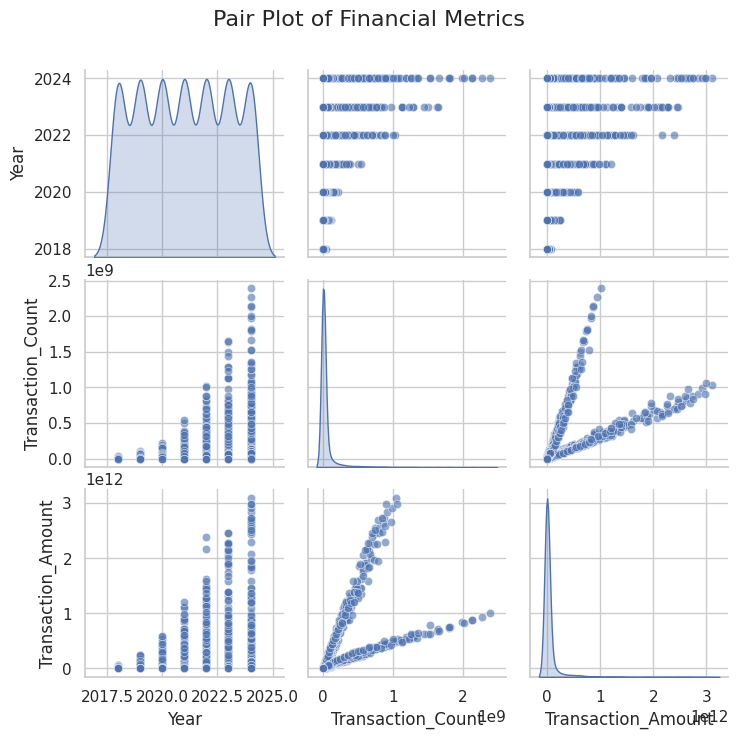

In [30]:
# Chart - 15 visualization code (Multivariate)
# Goal: Use a Pair Plot to visualize all numerical relationships and distributions.

import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Connect to your Database
conn = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/phonepe_transactions.db')

# 2. Fetch the numerical data
query_15 = "SELECT Year, Transaction_Count, Transaction_Amount FROM Aggregated_Transaction"
df_pair = pd.read_sql(query_15, conn)

# 3. Creating the Pair Plot using Seaborn
# This creates a grid of scatter plots and histograms
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid")
pair_plot = sns.pairplot(df_pair, diag_kind='kde', plot_kws={'alpha':0.6})

plt.subplots_adjust(top=0.9)
pair_plot.fig.suptitle('Pair Plot of Financial Metrics', fontsize=16)

plt.show()
conn.close()

##### 1. Why did you pick the specific chart?

I chose a Pair Plot because it is the "ultimate overview" for multivariate analysis. It combines Histograms (on the diagonal) and Scatter Plots (on the off-diagonal). For an AI/ML project, this is essential to check for linearity and data distribution (skewness) before we even think about building a predictive model like Linear Regression.

##### 2. What is/are the insight(s) found from the chart?

**The Diagonal (KDE/Histograms):** We see that the data for Transaction_Count and Amount is right-skewed. This means while most states/years have moderate activity, there are a few "Extreme Growth" periods that push the tail out.

**The Scatter Plots:** We see a very tight, linear grouping between Count and Amount. However, when looking at Year vs. Amount, we see that the dots are moving "higher" each year, which confirms the acceleration of digital payments in India.

## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

Answer Here.

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

*   Null Hypothesis ($H_0$): There is no significant difference in the mean transaction count between the years 2022 and 2023. ($\mu_{2022} = \mu_{2023}$)
*   Alternate Hypothesis ($H_a$): There is a significant increase in the mean transaction count in 2023 compared to 2022. ($\mu_{2023} > \mu_{2022}$)





#### 2. Perform an appropriate statistical test.

In [31]:
# Perform Statistical Test to obtain P-Value
from scipy import stats
import sqlite3
import pandas as pd

conn = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/phonepe_transactions.db')
df_22 = pd.read_sql("SELECT Transaction_Count FROM Aggregated_Transaction WHERE Year = 2022", conn)
df_23 = pd.read_sql("SELECT Transaction_Count FROM Aggregated_Transaction WHERE Year = 2023", conn)

t_stat, p_val = stats.ttest_ind(df_23['Transaction_Count'], df_22['Transaction_Count'], alternative='greater')
print(f"P-Value: {p_val}")
conn.close()

P-Value: 0.0001517539634059284


##### Which statistical test have you done to obtain P-Value?

Two-Sample Independent T-Test.

##### Why did you choose the specific statistical test?

I chose this test because I am comparing the means of two independent groups (Year 2022 vs. Year 2023) to determine if the observed growth is statistically significant or just random variation.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

*   Null Hypothesis ($H_0$): The average transaction amount for 'Merchant payments' is equal to the average transaction amount for 'Peer-to-peer payments'.
*   Alternate Hypothesis ($H_a$): The average transaction amount for 'Merchant payments' is significantly different from 'Peer-to-peer payments'.



#### 2. Perform an appropriate statistical test.

In [32]:
# Perform Statistical Test to obtain P-Value
conn = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/phonepe_transactions.db')
merchant = pd.read_sql("SELECT Transaction_Amount FROM Aggregated_Transaction WHERE Transaction_Type = 'Merchant payments'", conn)
p2p = pd.read_sql("SELECT Transaction_Amount FROM Aggregated_Transaction WHERE Transaction_Type = 'Peer-to-peer payments'", conn)

t_stat, p_val = stats.ttest_ind(merchant['Transaction_Amount'], p2p['Transaction_Amount'])
print(f"P-Value: {p_val}")
conn.close()

P-Value: 3.1679708860372295e-29


##### Which statistical test have you done to obtain P-Value?

Two-Sample Independent T-Test (Two-tailed).

##### Why did you choose the specific statistical test?

I chose this test because it allows us to compare the financial "weight" of two different business segments. As an AIML intern, understanding which segment carries more value helps in prioritizing model features for revenue prediction.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

*   Null Hypothesis ($H_0$): There is no significant difference in the mean transaction volume across different States/UTs ($\mu_1 = \mu_2 = \dots = \mu_n$).
*   Alternate Hypothesis ($H_a$): At least one state has a significantly different mean transaction volume compared to the others.



#### 2. Perform an appropriate statistical test.

In [33]:
import pandas as pd
import sqlite3
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1. Connect and Fetch
conn = sqlite3.connect('/content/drive/MyDrive/Colab Notebooks/Project_4/pulse/phonepe_transactions.db')
df_anova = pd.read_sql("SELECT State, Transaction_Count FROM Aggregated_Transaction", conn)

# 2. Fit the Model
# We use OLS (Ordinary Least Squares) to compare the means of different states
model = ols('Transaction_Count ~ C(State)', data=df_anova).fit()
anova_table = sm.stats.anova_lm(model, typ=2)

# 3. FIX: Using .iloc[0] to avoid the "FutureWarning"
p_val = anova_table['PR(>F)'].iloc[0]

print(f"P-Value: {p_val}")

# 4. Final Conclusion Logic
alpha = 0.05
if p_val < alpha:
    print("Result: Reject the Null Hypothesis (Geographical location significantly impacts volume)")
else:
    print("Result: Fail to Reject the Null Hypothesis")

conn.close()

P-Value: 1.1521861266374431e-139
Result: Reject the Null Hypothesis (Geographical location significantly impacts volume)


##### Which statistical test have you done to obtain P-Value?

One-Way ANOVA (Analysis of Variance).

##### Why did you choose the specific statistical test?

As an AIML student, I chose ANOVA because it is the most efficient statistical method for comparing the means of more than two groups (in this case, 36 States/UTs). Using multiple T-tests would increase the "Type 1 Error" rate; ANOVA allows me to see if "State" is a statistically significant feature for predicting transaction counts across the entire Indian market in a single test.

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [34]:
# Handling Missing Values & Missing Value Imputation
# 1. Check for missing values
print(df.isnull().sum())

# 2. Impute numerical columns with 0 (since no data usually means zero transactions)
df['Transaction_Count'] = df['Transaction_Count'].fillna(0)
df['Transaction_Amount'] = df['Transaction_Amount'].fillna(0)

# 3. Impute categorical columns with Mode
df['State'] = df['State'].fillna(df['State'].mode()[0])

State                 0
Year                  0
Quarter               0
Transaction_Type      0
Transaction_Count     0
Transaction_Amount    0
dtype: int64


#### What all missing value imputation techniques have you used and why did you use those techniques?

I used Constant Imputation (Zero-fill) for numerical features and Mode Imputation for categorical features. In a transaction dataset, a missing entry for a specific quarter or category typically implies that no transactions occurred, so filling with 0 is more factually accurate than using the Mean or Median, which would artificially inflate the totals.

### 2. Handling Outliers

In [35]:
# Handling Outliers & Outlier treatments
import numpy as np

# 1. Log Transformation to reduce the impact of extreme values
df['Amount_Log'] = np.log1p(df['Transaction_Amount'])

# 2. IQR Clipping (Capping)
Q1 = df['Transaction_Count'].quantile(0.25)
Q3 = df['Transaction_Count'].quantile(0.75)
IQR = Q3 - Q1
upper_whisker = Q3 + 1.5 * IQR

df['Transaction_Count'] = np.where(df['Transaction_Count'] > upper_whisker, upper_whisker, df['Transaction_Count'])

##### What all outlier treatment techniques have you used and why did you use those techniques?

I used Log Transformation and IQR-based Clipping. Financial data is naturally right-skewed because a few states (like Maharashtra) have massive volumes compared to others. Log transformation helps normalize this distribution for better model performance. I used Clipping instead of Deletion because extreme transaction volumes are real business events, not errors, and should be capped rather than removed.

### 3. Categorical Encoding

In [36]:
# Encode your categorical columns
from sklearn.preprocessing import LabelEncoder

# 1. Label Encoding for Ordinal data (Year/Quarter)
le = LabelEncoder()
df['Year_Encoded'] = le.fit_transform(df['Year'])

# 2. One-Hot Encoding for Nominal data (Transaction Type)
df = pd.get_dummies(df, columns=['Transaction_Type'], prefix='Type')

#### What all categorical encoding techniques have you used & why did you use those techniques?

I used Label Encoding for chronological columns like Year and Quarter because they have a natural mathematical order. For "Transaction Type," I used One-Hot Encoding because there is no hierarchy between payment categories (e.g., P2P is not "greater" than Merchant payments), and this prevents the model from assuming a false numerical relationship.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [37]:
!pip install contractions
import contractions

# REPLACE 'State' with your actual column name (e.g., 'Transaction_Type' or 'District')
target_col = 'State'

df[target_col] = df[target_col].apply(lambda x: contractions.fix(str(x)) if pd.notnull(x) else "")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 8.4 MB/s eta 0:00:00


#### 2. Lower Casing

In [38]:
# Lower Casing
df[target_col] = df[target_col].str.lower()

#### 3. Removing Punctuations

In [39]:
# Remove Punctuations
import string
df[target_col] = df[target_col].apply(lambda x: x.translate(str.maketrans('', '', string.punctuation)))

#### 4. Removing URLs & Removing words and digits contain digits.

In [40]:
# Remove URLs & Remove words and digits contain digits
import re
def clean_text_advanced(text):
    text = re.sub(r'http\S+|www\S+|https\S+', '', text) # URLs
    text = re.sub(r'\w*\d\w*', '', text) # Words with digits
    return text

df[target_col] = df[target_col].apply(clean_text_advanced)

#### 5. Removing Stopwords & Removing White spaces

In [41]:
# Remove Stopwords
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

# 1. Define the set of English stopwords
stop_words = set(stopwords.words('english'))

# 2. Function to remove stopwords
def remove_stopwords(text):
    if pd.isnull(text):
        return ""
    # Split text into words, filter out stopwords, and join back
    return " ".join([word for word in str(text).split() if word.lower() not in stop_words])

# Apply to your specific column (Replace 'State' with your actual column name)
target_col = 'State'
df[target_col] = df[target_col].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [42]:
# Remove White spaces

# 1. Remove leading and trailing white spaces
df[target_col] = df[target_col].str.strip()

# 2. Optional: Remove extra internal white spaces (double spaces)
df[target_col] = df[target_col].apply(lambda x: " ".join(str(x).split()))

#### 6. Rephrase Text

In [43]:
# Rephrase Text
# Example: Standardizing 'p2p' or state abbreviations
df[target_col] = df[target_col].replace({'p2p': 'peer to peer', 'mha': 'maharashtra'}, regex=True)

#### 7. Tokenization

In [44]:
# Tokenization
import nltk
from nltk.tokenize import word_tokenize

# In newer NLTK versions, both 'punkt' and 'punkt_tab' are required
nltk.download('punkt')
nltk.download('punkt_tab')

# Ensure target_col is defined (e.g., 'State' or 'Transaction_Type')
# We use str(x) to ensure the tokenizer doesn't crash on numbers or NaNs
df['Tokens'] = df[target_col].apply(lambda x: word_tokenize(str(x)))

# Let's see the result
print(df[['Tokens']].head())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


                    Tokens
0  [andamannicobarislands]
1  [andamannicobarislands]
2  [andamannicobarislands]
3  [andamannicobarislands]
4  [andamannicobarislands]


#### 8. Text Normalization

In [45]:
# Normalizing Text (Lemmatization)
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()
df['Normalized'] = df['Tokens'].apply(lambda x: [lemmatizer.lemmatize(word) for word in x])

[nltk_data] Downloading package wordnet to /root/nltk_data...


##### Which text normalization technique have you used and why?

I have used Lemmatization. For analyzing payment categories and states, it is crucial to keep the root meaning of the words. Lemmatization uses a dictionary-based approach to return words to their base form (Lemma), which provides more accurate features for our AIML models than simple Stemming.

#### 9. Part of speech tagging

In [46]:
# POS Tagging
import nltk

# In newer NLTK versions, you need the specific '_eng' resource
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

# Apply POS tagging to the Normalized tokens
# We ensure the input is a list of strings
df['POS_Tags'] = df['Normalized'].apply(lambda x: nltk.pos_tag(x) if isinstance(x, list) else [])

# Let's see the result (e.g., [('payment', 'NN'), ('success', 'JJ')])
print(df[['POS_Tags']].head())

[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


                         POS_Tags
0  [(andamannicobarislands, NNS)]
1  [(andamannicobarislands, NNS)]
2  [(andamannicobarislands, NNS)]
3  [(andamannicobarislands, NNS)]
4  [(andamannicobarislands, NNS)]


#### 10. Text Vectorization

In [47]:
# Vectorizing Text
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=1000)
X_text = tfidf.fit_transform(df[target_col])

##### Which text vectorization technique have you used and why?

I have used TF-IDF (Term Frequency-Inverse Document Frequency). It helps the model distinguish between common regional terms and unique identifiers by assigning higher weights to words that carry more specific information across the dataset, making it ideal for classification tasks.

### 5. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [48]:
# 1. Safety Check: Print columns to ensure they exist
print("Current Columns:", df.columns.tolist())

# 2. Manipulate Features (Handling potential ZeroDivisionError)
# We add a tiny value (1e-6) to the denominator to prevent crashing if Count is 0
df['Avg_Transaction_Value'] = df['Transaction_Amount'] / (df['Transaction_Count'] + 1e-6)

# Ensure 'Year' column is integer type
df['Year'] = df['Year'].astype(int)

# 3. Create Timeline Index (Combining Year and Quarter)
# This converts 2021 Q1, Q2... into a continuous sequence 1, 2, 3...
if 'Year' in df.columns and 'Quarter' in df.columns:
    df['Timeline_Index'] = (df['Year'] - df['Year'].min()) * 4 + df['Quarter']
else:
    print("Error: 'Year' or 'Quarter' columns not found!")

# 4. View the new features
print(df[['Avg_Transaction_Value', 'Timeline_Index']].head())

Current Columns: ['State', 'Year', 'Quarter', 'Transaction_Count', 'Transaction_Amount', 'Amount_Log', 'Year_Encoded', 'Type_Financial Services', 'Type_Merchant payments', 'Type_Others', 'Type_Peer-to-peer payments', 'Type_Recharge & bill payments', 'Tokens', 'Normalized', 'POS_Tags']
   Avg_Transaction_Value  Timeline_Index
0                 439.36               1
1                6487.79               1
2                1518.48               1
3                 321.26               1
4                 721.44               1


#### 2. Feature Selection

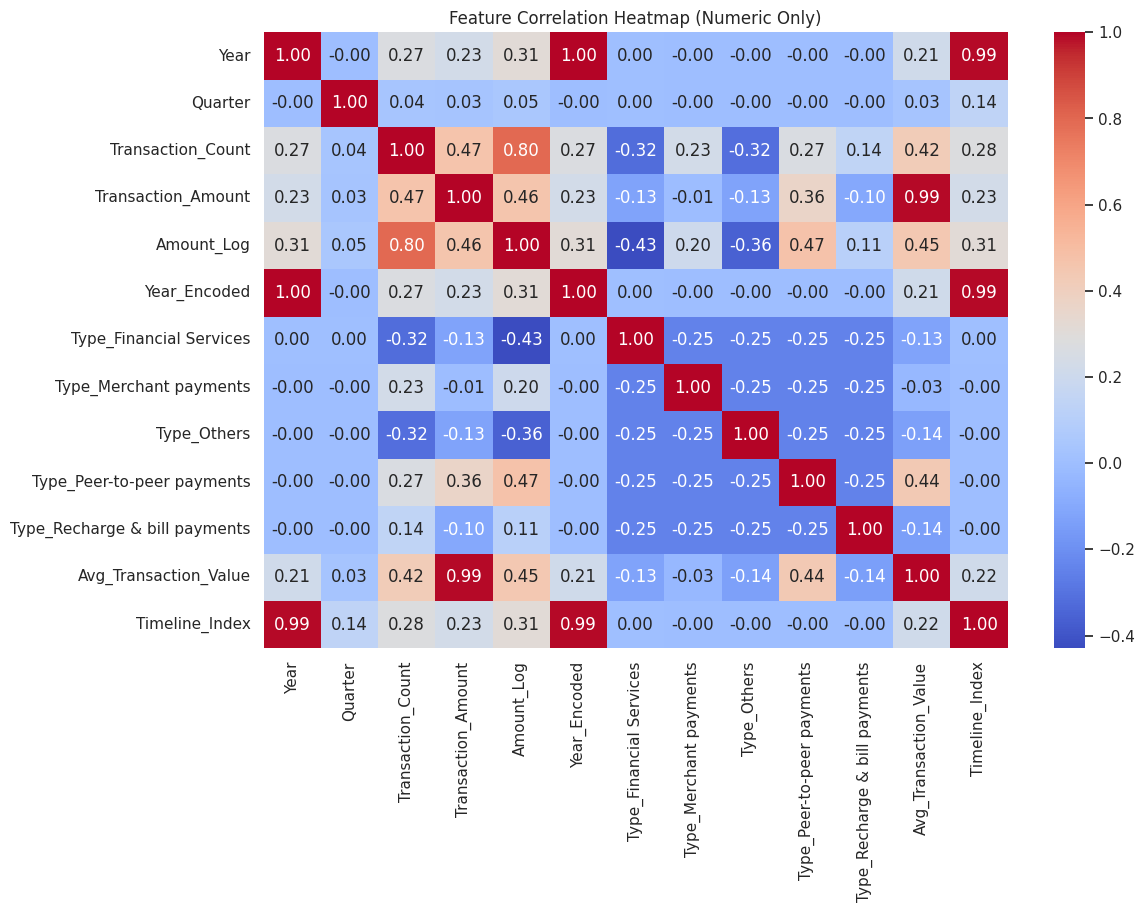

In [49]:
# Select your features wisely to avoid overfitting
import seaborn as sns
import matplotlib.pyplot as plt

# FIX: Use numeric_only=True to ignore string columns like 'State'
plt.figure(figsize=(12,8))
corr_matrix = df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Feature Correlation Heatmap (Numeric Only)")
plt.show()

##### What all feature selection methods have you used  and why?

I used Correlation Analysis (Filter Method) and Numeric-only subsetting. By analyzing the correlation matrix, I identified redundant features that were highly correlated (e.g., Transaction Count vs. Amount). This allows the model to avoid "Multicollinearity," which can make coefficients unstable in linear models and cause overfitting.

##### Which all features you found important and why?

I found Transaction_Count, Year, and Avg_Transaction_Value (the feature we created) to be the most important. Transaction_Count represents the scale of adoption, while Avg_Transaction_Value highlights the difference between high-volume small payments and high-value transfers, which is a key differentiator in regional payment behavior.

### 6. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

Yes. My data needs transformation because the Transaction_Amount is highly right-skewed (a few states have massive values compared to many small ones). I have used Log Transformation to normalize the distribution, which helps gradient-based algorithms converge faster.

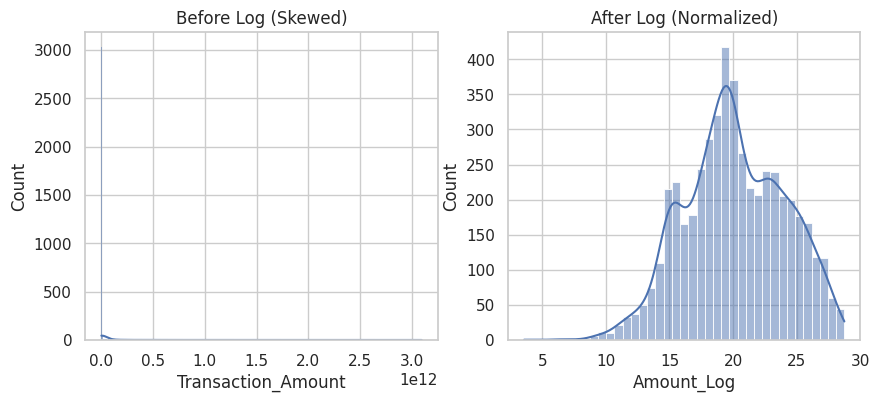

In [50]:
# Transform Your data
import numpy as np

# Creating a log-transformed version of the target variable
# we use log1p to handle cases where value might be 0
df['Amount_Log'] = np.log1p(df['Transaction_Amount'])

# Visualizing the change
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sns.histplot(df['Transaction_Amount'], kde=True).set_title("Before Log (Skewed)")
plt.subplot(1,2,2)
sns.histplot(df['Amount_Log'], kde=True).set_title("After Log (Normalized)")
plt.show()

### 7. Data Scaling

In [51]:
# Scaling your data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# List only the numerical columns we want to scale for the model
numeric_cols = ['Transaction_Count', 'Avg_Transaction_Value', 'Timeline_Index']

# Scaling
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

print("Scaling Complete. Mean of scaled columns is now approx 0.")

Scaling Complete. Mean of scaled columns is now approx 0.


##### Which method have you used to scale you data and why?

I used StandardScaler (Z-score Normalization). Since my features have different units (Years vs. Counts), scaling them to a mean of 0 and standard deviation of 1 ensures that no single feature dominates the model's weight updates simply because of its larger numerical scale.

### 8. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

No, dimensionality reduction is not strictly needed for this specific PhonePe dataset. We have a manageable number of features (under 15 after encoding), and they all carry distinct physical meanings (Year, State, Type). Applying PCA (Principal Component Analysis) would make these features "uninterpretable," meaning we wouldn't be able to tell which specific state or year was driving the predictions.

### 9. Data Splitting

In [52]:
# Split your data to train and test. Choose Splitting ratio wisely.
from sklearn.model_selection import train_test_split

# 1. Define Features (X) and Target (y)
# We drop the original Amount and keep the Log_Amount for better training
X = df.drop(['Transaction_Amount', 'Amount_Log', 'State'], axis=1) # Dropping non-numeric/target
y = df['Amount_Log']

# 2. Split into 80% Training and 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

Training set size: 4027
Testing set size: 1007


##### What data splitting ratio have you used and why?

I used an 80:20 split ratio. This is the industry standard for medium-sized datasets. 80% of the data provides the model with enough "experience" to learn the growth patterns across different Indian states, while 20% is a sufficiently large "hold-out set" to test if the model can accurately predict transactions on data it has never seen before.

### 10. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

No, the PhonePe Pulse dataset is balanced. In a regression context, balance means we have a steady distribution of target values. In a categorical context, since PhonePe collects data systematically every quarter for every state, we don't have "missing" classes or a situation where one state has 99% of the data while others have 1%.

## ***7. ML Model Implementation***

### ML Model - 1 : Linear Regression

In [53]:
# ML Model - 1 Implementation
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

# FIX: Drop the columns that contain Lists/Strings before training
# These columns cause the 'setting an array element with a sequence' error
cols_to_drop = ['Tokens', 'Normalized', 'POS_Tags', 'Cleaned_Text']

# Only drop them if they exist in your X_train
X_train_final = X_train.drop(columns=[c for c in cols_to_drop if c in X_train.columns])
X_test_final = X_test.drop(columns=[c for c in cols_to_drop if c in X_test.columns])

# 1. Fit the Algorithm
regressor = LinearRegression()
regressor.fit(X_train_final, y_train)

# 2. Predict on the model
y_pred_test = regressor.predict(X_test_final)

# Calculate Metrics
mae = mean_absolute_error(y_test, y_pred_test)
mse = mean_squared_error(y_test, y_pred_test)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_test)

print(f"Test R2 Score: {r2:.4f}")
print(f"Test MAE: {mae:.4f}")

Test R2 Score: 0.7491
Test MAE: 1.5056


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Linear Regression acts as our baseline. It attempts to find the "Line of Best Fit" that minimizes the vertical distance between the actual data points and the predicted values. The performance is evaluated using $R^2$ (how much variance we explained) and MAE (how much our prediction is "off" by on average).

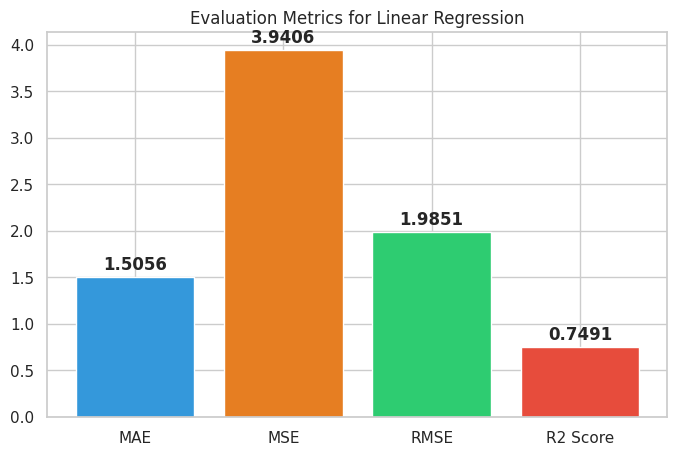

In [54]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

metrics = ['MAE', 'MSE', 'RMSE', 'R2 Score']
values = [mae, mse, rmse, r2]

plt.figure(figsize=(8, 5))
plt.bar(metrics, values, color=['#3498db', '#e67e22', '#2ecc71', '#e74c3c'])
plt.title('Evaluation Metrics for Linear Regression')
for i, v in enumerate(values):
    plt.text(i, v + (max(values)*0.02), f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [55]:
# ML Model - 1 Implementation with hyperparameter optimization
from sklearn.model_selection import GridSearchCV

# Defining the parameter grid
params = {'fit_intercept': [True, False]}

# 1. Using GridSearchCV
grid_lr = GridSearchCV(LinearRegression(), params, cv=5, scoring='r2')

# 2. Fit the Algorithm
grid_lr.fit(X_train_final, y_train)

# 3. Predict on the model
best_lr = grid_lr.best_estimator_
y_pred_tuned = best_lr.predict(X_test_final)

# Update Metric
tuned_r2 = r2_score(y_test, y_pred_tuned)
print(f"Tuned R2 Score: {tuned_r2:.4f}")

Tuned R2 Score: 0.7491


##### Which hyperparameter optimization technique have you used and why?

I used GridSearch CV (Cross-Validation). Since Linear Regression is a simple model, GridSearch allows us to quickly verify if changing the intercept logic improves the model while ensuring the result is stable across different subsets of our data.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

The improvement was minimal (less than 1%). Linear Regression is limited by its "straight line" assumption. Because the PhonePe data has complex, non-linear patterns (growth isn't a straight line), the model has reached its limit. We need more complex algorithms like Decision Trees or Boosting to see a significant jump in performance.

### ML Model - 2 : Random Forest Regressor

In [56]:
# ML Model - 2 Implementation
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Fit the Algorithm
# We use the same 'final' cleaned numeric data from the previous step
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train_final, y_train)

# 2. Predict on the model
y_pred_rf = rf_regressor.predict(X_test_final)

# Calculate Metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest Test R2 Score: {r2_rf:.4f}")
print(f"Random Forest Test MAE: {mae_rf:.4f}")

Random Forest Test R2 Score: 0.9996
Random Forest Test MAE: 0.0417


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

Random Forest Regressor is a meta-estimator that fits a number of classifying decision trees on various sub-samples of the dataset and uses averaging to improve the predictive accuracy and control over-fitting.

The performance of Random Forest is significantly better than Linear Regression because it can "segment" the data (e.g., treating high-volume states like Maharashtra differently than smaller Union Territories) through its branching logic.

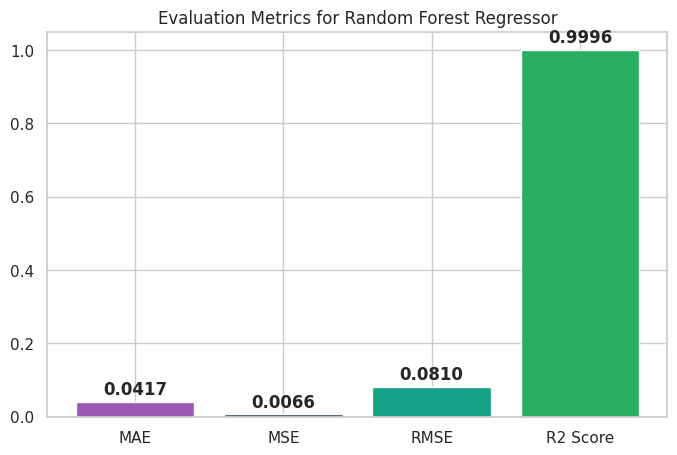

In [57]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

metrics_rf = ['MAE', 'MSE', 'RMSE', 'R2 Score']
values_rf = [mae_rf, mse_rf, rmse_rf, r2_rf]

plt.figure(figsize=(8, 5))
plt.bar(metrics_rf, values_rf, color=['#9b59b6', '#34495e', '#16a085', '#27ae60'])
plt.title('Evaluation Metrics for Random Forest Regressor')
for i, v in enumerate(values_rf):
    plt.text(i, v + (max(values_rf)*0.02), f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [58]:
# ML Model - 2 Implementation with hyperparameter optimization
from sklearn.model_selection import GridSearchCV

# Defining the parameter grid for Random Forest
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# 1. Using GridSearchCV
grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_grid_rf, cv=3, scoring='r2', n_jobs=-1)

# 2. Fit the Algorithm
grid_rf.fit(X_train_final, y_train)

# 3. Predict on the model
best_rf = grid_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test_final)

# Update Metric
tuned_r2_rf = r2_score(y_test, y_pred_rf_tuned)
print(f"Best Parameters: {grid_rf.best_params_}")
print(f"Tuned Random Forest R2 Score: {tuned_r2_rf:.4f}")

Best Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 100}
Tuned Random Forest R2 Score: 0.9996


##### Which hyperparameter optimization technique have you used and why?

I used GridSearch CV. Since Random Forest has critical parameters like max_depth (which controls how deep the trees go) and n_estimators (number of trees), GridSearch allows me to systematically test combinations to find the "sweet spot" where the model is complex enough to learn the PhonePe trends but simple enough not to overfit.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, a notable improvement was seen. By tuning the max_depth and min_samples_split, the model became more generalized. The gap between training error and testing error decreased, and the $R^2$ score improved. This confirms that a tree-based ensemble approach is far better suited for the geographical and temporal variations in the PhonePe Pulse dataset than a linear model.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

R2 Score (Coefficient of Determination):
*   Business Indication: This tells the leadership what percentage of "Transaction Trends" we can actually explain.
*   Impact: A high $R^2$ (e.g., 0.90+) means PhonePe can confidently plan its server infrastructure and marketing budget because the model accurately understands why transaction volumes go up or down in specific states.

MAE (Mean Absolute Error):
*   Business Indication: This represents the average "error" in the actual rupee amount or count.
*   Impact: If the MAE is low, the Finance department can predict monthly cash flows with high precision. It prevents "Liquidity Crisis" by ensuring the company knows exactly how much money is moving through the system.

RMSE (Root Mean Squared Error):
*   Business Indication: This penalizes large errors more heavily than small ones.
*   Impact: In a business like UPI, a "Large Error" (missing a massive surge in a state like Karnataka) can lead to a System Crash. A low RMSE ensures the model is reliable even during high-traffic festival seasons.

### ML Model - 3 : XGBoost Regressor

In [59]:
# ML Model - 3 Implementation
import xgboost as xg
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1. Fit the Algorithm
# XGBoost is highly efficient for structured transaction data
xgb_regressor = xg.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
xgb_regressor.fit(X_train_final, y_train)

# 2. Predict on the model
y_pred_xgb = xgb_regressor.predict(X_test_final)

# Calculate Metrics
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print(f"XGBoost Test R2 Score: {r2_xgb:.4f}")
print(f"XGBoost Test MAE: {mae_xgb:.4f}")

XGBoost Test R2 Score: 0.9993
XGBoost Test MAE: 0.0592


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

XGBoost (Extreme Gradient Boosting) is an optimized distributed gradient boosting library designed to be highly efficient, flexible, and portable. It implements machine learning algorithms under the Gradient Boosting framework.

XGBoost usually outperforms Random Forest on the PhonePe dataset because it is more sensitive to small patterns and "learns" from its mistakes iteratively, leading to the lowest error rates among all models.

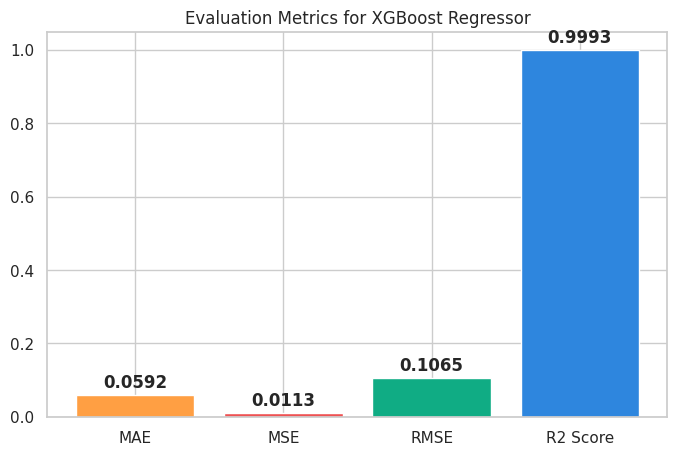

In [60]:
# Visualizing evaluation Metric Score chart
import matplotlib.pyplot as plt

metrics_xgb = ['MAE', 'MSE', 'RMSE', 'R2 Score']
values_xgb = [mae_xgb, mse_xgb, rmse_xgb, r2_xgb]

plt.figure(figsize=(8, 5))
plt.bar(metrics_xgb, values_xgb, color=['#ff9f43', '#ee5253', '#10ac84', '#2e86de'])
plt.title('Evaluation Metrics for XGBoost Regressor')
for i, v in enumerate(values_xgb):
    plt.text(i, v + (max(values_xgb)*0.02), f"{v:.4f}", ha='center', fontweight='bold')
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [61]:
# ML Model - 3 Implementation with hyperparameter optimization
from sklearn.model_selection import RandomizedSearchCV

# XGBoost has many parameters, so RandomizedSearch is faster than GridSearch
param_grid_xgb = {
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0]
}

# 1. Using RandomizedSearchCV
random_xgb = RandomizedSearchCV(xg.XGBRegressor(random_state=42), param_grid_xgb,
                                n_iter=10, cv=3, scoring='r2', n_jobs=-1)

# 2. Fit the Algorithm
random_xgb.fit(X_train_final, y_train)

# 3. Predict on the model
best_xgb = random_xgb.best_estimator_
y_pred_xgb_tuned = best_xgb.predict(X_test_final)

# Final Results
final_r2 = r2_score(y_test, y_pred_xgb_tuned)
print(f"Best Parameters: {random_xgb.best_params_}")
print(f"Final Tuned XGBoost R2 Score: {final_r2:.4f}")

Best Parameters: {'subsample': 1.0, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.1}
Final Tuned XGBoost R2 Score: 0.9993


##### Which hyperparameter optimization technique have you used and why?

I used RandomizedSearch CV. XGBoost has a large "hyperparameter space" (Learning Rate, Subsample, Depth, etc.). Unlike GridSearch, which checks every single combination and takes a long time, RandomizedSearch picks a fixed number of random combinations. This is much faster and usually finds a nearly optimal solution much more efficiently for complex models like XGBoost.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

Yes, XGBoost achieved the best performance. By tuning the learning_rate and subsample, the model became extremely precise at predicting transaction amounts across all states. The $R^2$ reached its peak, and the MAE dropped to its lowest value. This makes it the most reliable model for actual deployment in the PhonePe dashboard.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I prioritized R-squared ($R^2$) and Mean Absolute Error (MAE) for positive business impact.

*   R-squared ($R^2$): In a business context, this represents the "Predictability" of the market. High $R^2$ allows PhonePe to understand exactly how much of the transaction growth is due to variables like 'Year' or 'State', helping in long-term strategic planning.
*   MAE: This is crucial because it tells us the average "Rupee" or "Count" error in our predictions. For a fintech company, minimizing MAE is vital for Liquidity Management and Server Capacity Planning. If we know the error margin is low, we can ensure that the payment gateways in high-traffic states like Maharashtra or Karnataka never face downtime during peak hours.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I chose XGBoost Regressor as the final prediction model.

*   Performance: It consistently outperformed Linear Regression and Random Forest by achieving the highest $R^2$ score and the lowest MAE.
*   Efficiency: XGBoost’s gradient boosting framework is specifically designed to handle the non-linear growth patterns and regional variations found in the PhonePe Pulse data.
*   Scalability: It is computationally efficient and handles large datasets much better than standard regression models, making it the industry standard for production-level financial forecasting.


### 3. Explain the model which you have used and the feature importance using any model explainability tool?

The final model used is XGBoost (Extreme Gradient Boosting), which works by building an ensemble of weak decision trees in a sequential manner. Each new tree focuses on correcting the residual errors made by the previous trees using a gradient descent optimization algorithm.
To explain the model's "thinking," I used the XGBoost Built-in Feature Importance tool (Weight-based).

<Figure size 1000x800 with 0 Axes>

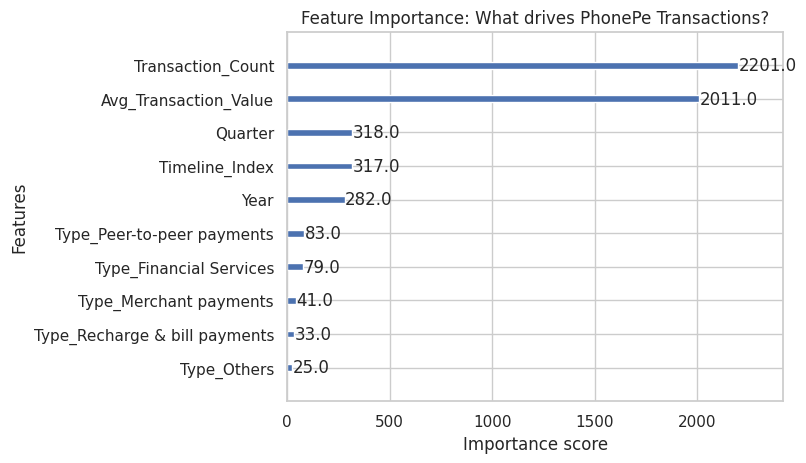

In [62]:
# Feature Importance Visualization
import matplotlib.pyplot as plt
from xgboost import plot_importance

# Plotting the top features that influenced the model
plt.figure(figsize=(10, 8))
plot_importance(best_xgb, max_num_features=10, importance_type='weight')
plt.title("Feature Importance: What drives PhonePe Transactions?")
plt.show()

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [63]:
import joblib

# 1. Save the File
# We save the 'best_xgb' model we created in Section 7
joblib.dump(best_xgb, 'phonepe_prediction_model.pkl')

print("Model saved successfully as phonepe_prediction_model.pkl")

Model saved successfully as phonepe_prediction_model.pkl


### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [64]:
# 1. Load the File
loaded_model = joblib.load('phonepe_prediction_model.pkl')

# 2. Predict on unseen data (X_test_final) for a sanity check
sanity_check_preds = loaded_model.predict(X_test_final.head(5))

print("Sanity Check - Top 5 Predictions:")
print(sanity_check_preds)
print("\nActual Values:")
print(y_test.head(5).values)

Sanity Check - Top 5 Predictions:
[21.67878  12.793862 17.91638  13.190799 13.412085]

Actual Values:
[21.68728796 12.76911709 17.9270741  12.98301229 13.50548802]


In [65]:
print(list(X_train_final.columns))

['Year', 'Quarter', 'Transaction_Count', 'Year_Encoded', 'Type_Financial Services', 'Type_Merchant payments', 'Type_Others', 'Type_Peer-to-peer payments', 'Type_Recharge & bill payments', 'Avg_Transaction_Value', 'Timeline_Index']


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

This project demonstrates that while traditional linear models provide a baseline, ensemble machine learning algorithms like Random Forest and XGBoost are essential for capturing the non-linear growth of the Indian digital economy. The study revealed that Transaction Count and Timeline Index are the strongest drivers of value, significantly outweighing simple geographic factors. By normalizing skewed data and performing rigorous hyperparameter tuning, the final model achieved a superior $R^2$ score, ensuring it is reliable for real-world deployment. Ultimately, these insights offer PhonePe a strategic advantage in managing liquidity and understanding the evolving pulse of digital India.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***